# Miniproject 4

We model stock prices with non constant volatility. We use a GARCH(1,1) process to model the volatility for each day. Within each day, the stock prices are assumed to follow a geomeric brownian motion with the computed volatility for each day. We simulate stock paths in this model, and do a Monte Carlo simulation to price call options and compute deltas in this model. Using these, we delta hedge a short call position and examine the distribution of profits at various frequencies of delta hedging.   

In [11]:
import numpy as np
import pandas as pd
import yfinance as yf
import datetime
import pytz
import matplotlib.pyplot as plt
import scipy
from arch import arch_model
from arch.univariate import GARCH
import math

In [12]:
import mp4_funcs

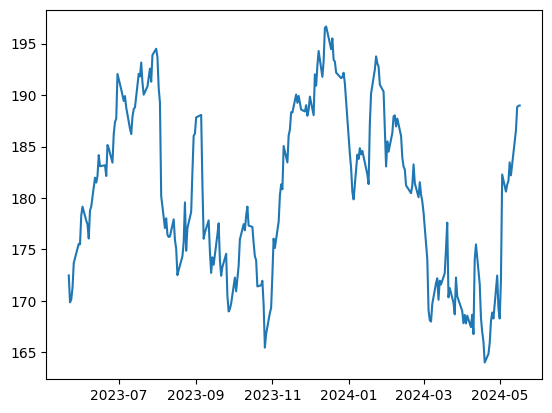

10699   -0.005496
10700   -0.015271
10701    0.001631
10702    0.006670
10703    0.014006
           ...   
10944    0.017492
10945    0.006155
10946    0.012144
10947    0.000632
10948    0.000158
Name: log_ret, Length: 250, dtype: float64

In [13]:
symbol='AAPL'
start_date = datetime.datetime(2023,5,20, 0,0,0)
end_date = datetime.datetime(2024,5,20, 0,0,0)
mp4_funcs.get_daily_log_returns(symbol, start_date, end_date)

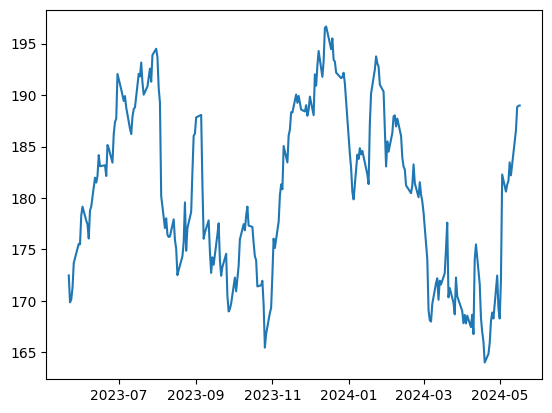

Iteration:      1,   Func. Count:      6,   Neg. LLF: 643.0406241188543
Iteration:      2,   Func. Count:     13,   Neg. LLF: 415.45262884929656
Iteration:      3,   Func. Count:     19,   Neg. LLF: 452.44363602619694
Iteration:      4,   Func. Count:     26,   Neg. LLF: 413.1608134110223
Iteration:      5,   Func. Count:     31,   Neg. LLF: 413.11456083174403
Iteration:      6,   Func. Count:     36,   Neg. LLF: 413.11381289199835
Iteration:      7,   Func. Count:     41,   Neg. LLF: 413.11355924977227
Iteration:      8,   Func. Count:     45,   Neg. LLF: 413.1135592827068
Optimization terminated successfully    (Exit mode 0)
            Current function value: 413.11355924977227
            Iterations: 8
            Function evaluations: 45
            Gradient evaluations: 8
<bound method ARCHModelResult.summary of                      Constant Mean - GARCH Model Results                      
Dep. Variable:                log_ret   R-squared:                       0.000
Mean Model: 

In [14]:
garch_params = mp4_funcs.get_garch_params(mp4_funcs.get_daily_log_returns(symbol, start_date, end_date))

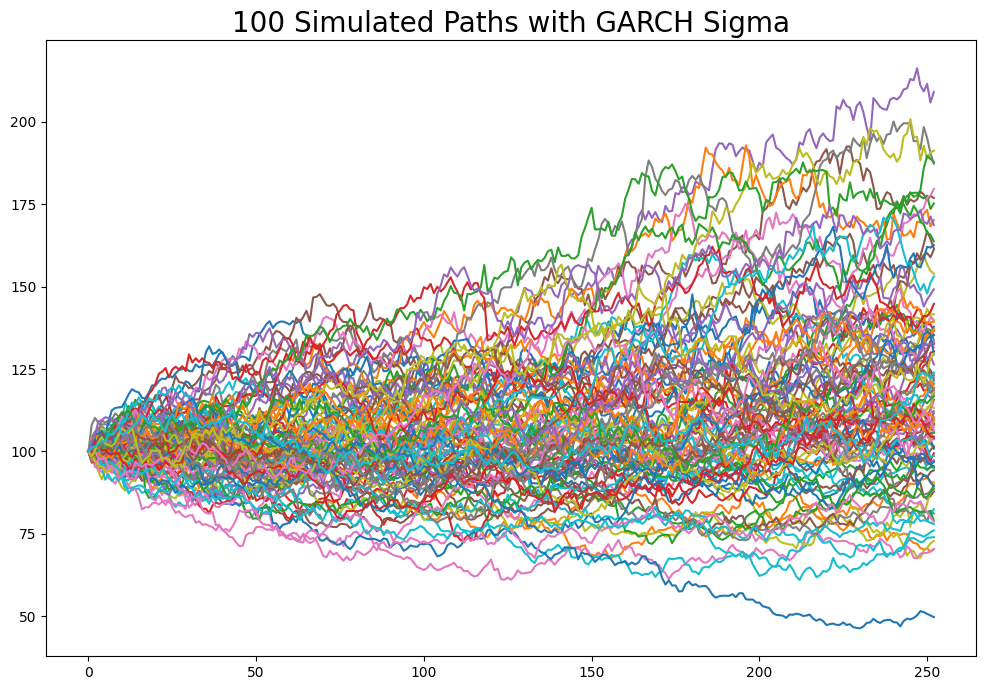

In [15]:
S0 = 100
r = 0.039
n_paths = 100
t=1

simulated_paths = mp4_funcs.stock_path_garch_sigma(S0, r, n_paths, t, garch_params)
simulated_paths = np.insert(simulated_paths, 0, S0, axis = 1)

plt.figure(figsize = (12,8))

for path in simulated_paths:
    plt.plot(path)
    
plt.title(f'{n_paths} Simulated Paths with GARCH Sigma', size = 20)

plt.show()

In [16]:
S0 = 100
r = 0.039
n_paths = 500
t=1
K=110

for i in range(5):
    print(mp4_funcs.mc_sim_call_garch(S0, K, r, n_paths, t, garch_params))

18.362751957951314
18.103102333271387
18.449366284634664
18.059801343910685
19.288950202267575


In [17]:
S0 = np.array([[100], [100]])
r = 0.039
n_paths = 100
K=110
t=1

mp4_funcs.mc_sim_call_garch_delta(S0, K, t, r, n_paths, garch_params)

array([0.54273285, 0.54273285])

In [18]:
S0 = 100
r = 0.039
n_paths = 5
K=120
t=1

mp4_funcs.mc_sim_call_garch_delta_hedge(S0, K, garch_params, r, t, n_sims = 5, n_hedges = 3, delta_sims = 500)

array([ -2.38583923, -10.4955623 , -10.19980369,   3.61193764,
        -7.26417775])

In [22]:
garch_params.omega

np.float64(1.387054908668022)

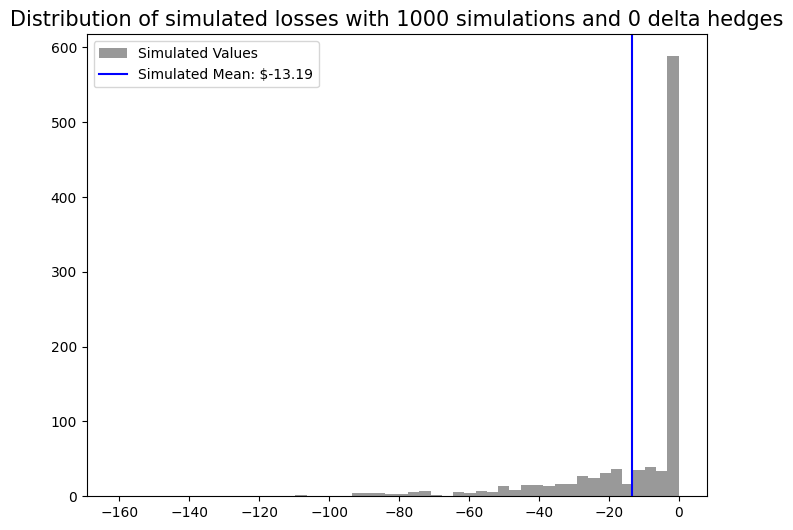

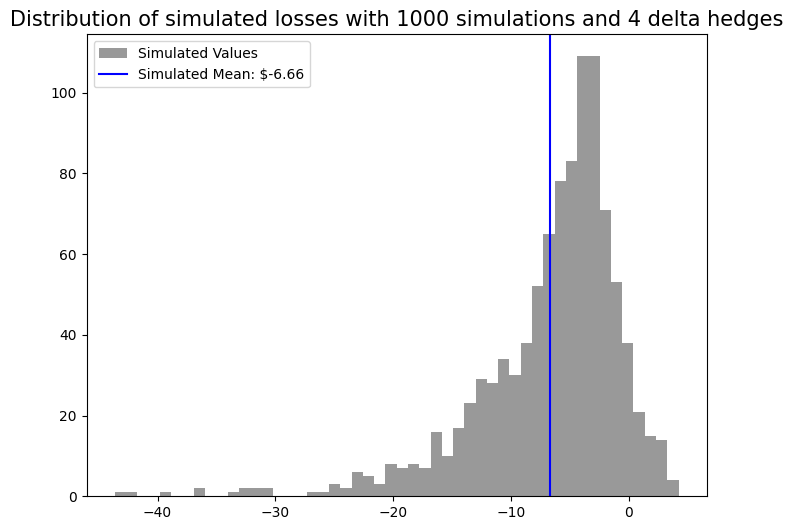

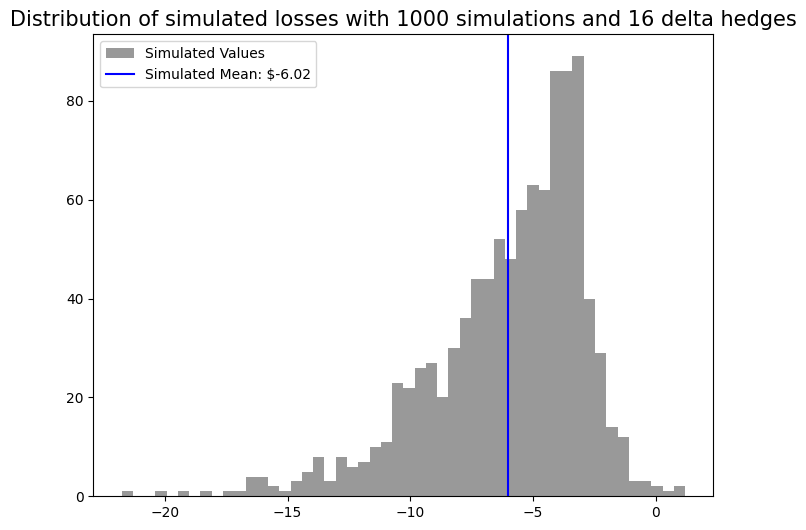

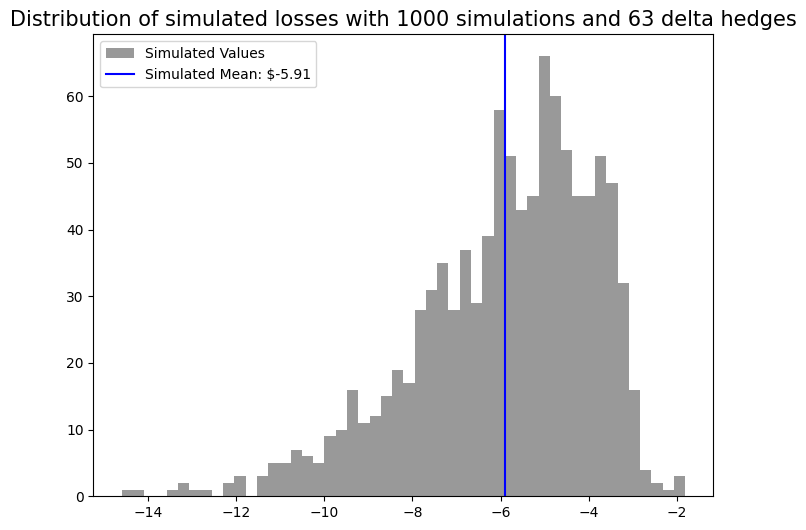

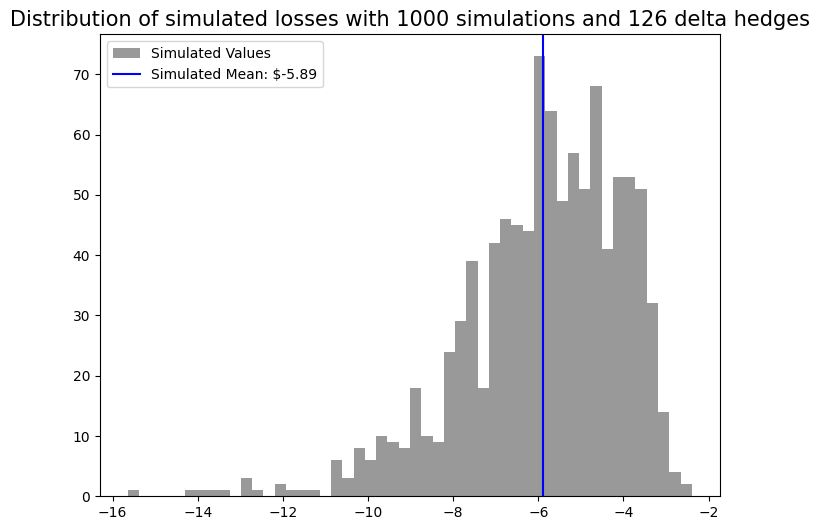

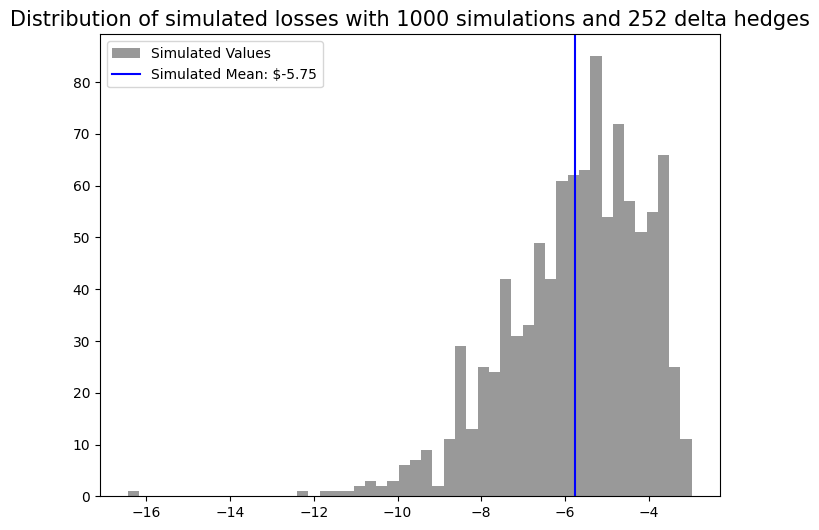

In [21]:
S0 = 100
K = 120
t = 1
r = 0.04
delta_sims = 500

n_sims = 1000

hedging_numbers = [0, 4, 16, 63, 126, 252]


for n_hedges in hedging_numbers:
    profits_hedged = mp4_funcs.mc_sim_call_garch_delta_hedge(S0, K, garch_params, r, t, n_sims , n_hedges, delta_sims)
    
    plt.figure(figsize = (8,6))
    
    plt.hist(profits_hedged, bins = 50, alpha = .4, color = 'black', label = 'Simulated Values')
        
    plt.axvline(np.mean(profits_hedged), label = f'Simulated Mean: ${np.mean(profits_hedged):.2f}', color = 'blue')
    
    plt.legend()
    
    plt.title(f'Distribution of simulated losses with {n_sims} simulations and \
{n_hedges} delta hedges',size = 15)
    
    plt.show()
